### 🧠 Neural Networks: Traditional vs. CNN

| Feature | Traditional Neural Networks | Convolutional Neural Networks (CNNs) |
| :--- | :--- | :--- |
| **How they "see"** | Very rigid; can only read data in a single straight line (1D arrays). | Built to process 2D grids; looks at images the way human eyes do. |
| **Spatial Awareness** | Poor. Requires "flattening" the image, which destroys the shape and structure. | Excellent. Keeps the image grid intact, preserving "up, down, left, right." |

### ⚙️ The Mechanics of a CNN

> *Instead of forcing every neuron to look at the entire image at the exact same time, a CNN uses tiny **"filters"** (like magnifying glasses).*

**1. The Process**
A small filter (e.g., a 3x3 square of pixels) slides across the image, scanning it sequentially from top-left to bottom-right.

**2. The Purpose**
Instead of processing the entire picture at once, the filter focuses solely on finding one specific feature in that small window—such as a vertical edge, a curve, or a specific patch of color.

### 🤝 Parameter Sharing (The Magic of CNNs)

If a CNN learns that a specific filter is really good at finding the edge of a cat's ear in the top-left corner of an image, it uses the **exact same filter** to scan for cat ears across the rest of the image.

**The Result:** Because it reuses the filter, the CNN requires only a fraction of the parameters that a standard neural network needs. 
* ⚡ **Fast:** Requires significantly less computing power.
* 🎯 **Accurate:** Remarkably good at finding patterns no matter where they are in the image.

In [1]:
import tensorflow as tf

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

### 📊 Dataset: CIFAR-10

In the code below, we load the dataset and **normalize** the pixel values (converting them from a scale of 0-255 down to a scale of 0.0-1.0).

**Why do we do this?**
Because neural networks learn much faster and more reliably when dealing with small, uniform numbers. 

* ⚡ **Speed:** If we feed the network large numbers (like 255), the internal math gets messy and training slows to a crawl.
* ⚖️ **Stability:** Keeping the inputs between 0 and 1 stops the parameters from swinging wildly out of control, giving the network an easy path to learn the features of the image.

In [7]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

### 👁️ Verify the Data

To verify that the dataset loaded correctly and the images match their labels, we will plot the first 25 images from the training set and display the corresponding class name below each image:

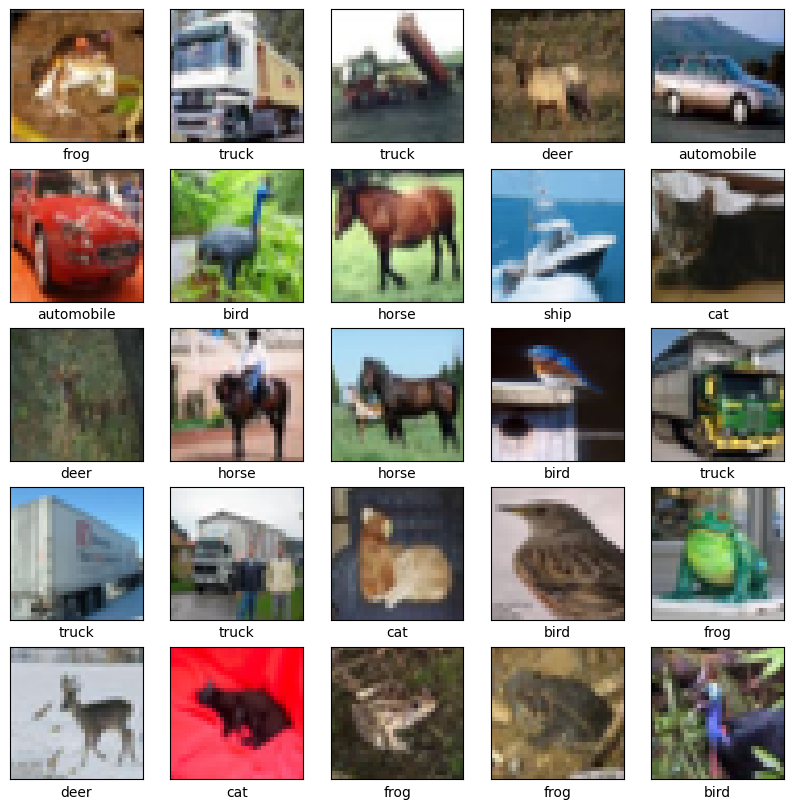

In [11]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

### 📥 How the Image Enters the CNN

**1. The Convolutional Base (The Feature Extractor)**
The image is fed first into the convolutional base. This section acts as a dedicated feature extractor. It looks at the raw image and finds all the important patterns (edges, circles, colors).



**2. The Layers: Conv2D and MaxPooling2D**
The code uses an alternating stack of these two specific layers:
* 🕵️‍♂️ **`Conv2D` (The Detective):** This is the "magnifying glass." It slides a 2D filter over the image to find specific features like cat ears and tires.
* 🗜️ **`MaxPooling2D` (The Summarizer):** After the `Conv2D` finds a bunch of features, the image grid contains a lot of unnecessary data. The `MaxPooling2D` layer steps in and shrinks the image grid down, keeping only the "loudest," most important features. This saves a massive amount of computing power.

**3. Understanding the Input Shape: `(32, 32, 3)`**
Color images are 3D data blocks (called tensors). We must tell the very first layer exactly what size block to expect:
* ↕️ **Height:** 32 pixels
* ↔️ **Width:** 32 pixels
* 🎨 **Color Channels:** 3 (Red, Green, Blue)

In [21]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

### 🧠 Adding the Dense Layers (The Decision Makers)

To complete the model, we need to take all the features our CNN found and make a final decision: *What is this a picture of?* To do this, we use **Dense layers** (these are just traditional neural network layers). But we have a major problem: our CNN outputs a 3D block of data, and as we learned earlier, traditional networks can only read 1D straight lines!

**The Code Breakdown:**

* 🥞 **`model.add(layers.Flatten())`**
  This solves our 3D problem. The last output from our CNN was a tiny, thick block of features shaped as `(4, 4, 64)`. The `Flatten` layer literally unrolls this 3D block into one single, 1D straight line of 1,024 numbers.
  
* ⚖️ **`model.add(layers.Dense(64, activation='relu'))`**
  Now that the data is in a straight line, we feed it into a standard hidden layer with 64 neurons. Think of these 64 neurons as the judge looking at all the flattened clues and weighing the evidence. *(Note: `relu` is just a math filter that helps the network learn faster by turning any negative numbers into zeros).*
  
* 📢 **`model.add(layers.Dense(10))`**
  This is the final output layer. It has exactly **10 neurons** because the CIFAR-10 dataset has exactly 10 categories (airplane, dog, cat, etc.). The neuron that outputs the highest number is the network's final guess!

In [22]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

### 🎓 Compiling and Training 

Before a network can learn, we have to give it a syllabus and a grading rubric. Then, we force it to study. 

**1. `model.compile(...)`: Setting the Rules**
This step doesn't train the model; it just equips the model with the tools it needs to learn.
* 🛠️ **`optimizer='adam'` (The Tuner):** This is the algorithm that decides *how* to adjust the millions of parameters when the network makes a mistake. 
* ❌ **`loss=...` (The Red Pen):** This calculates exactly how wrong the network's guesses are. The optimizer uses this "error score" to know which parameters to modify.
* 💯 **`metrics=['accuracy']` (The Grade):** This tells the network we want to track the simple percentage of images it guesses correctly.

**2. `model.fit(...)`: The Actual Studying**
This is where the math happens and the network looks at the images.
* 📚 **`epochs=10`:** An "epoch" is one complete pass through the entire dataset. Setting this to 10 means the network will look through the entire "textbook" of images 10 times to memorize the patterns.
* 📝 **`validation_data=...` (The Quiz):** After every single epoch, we test the network on a separate pile of images it has **never seen before**. This proves the network is actually learning what a "cat" looks like, rather than just memorizing the specific cat photos from the textbook.

In [23]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4617 - loss: 1.4927 - val_accuracy: 0.5436 - val_loss: 1.2943
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6086 - loss: 1.1111 - val_accuracy: 0.6375 - val_loss: 1.0342
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6606 - loss: 0.9665 - val_accuracy: 0.6465 - val_loss: 1.0104
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6943 - loss: 0.8758 - val_accuracy: 0.6432 - val_loss: 1.0473
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7205 - loss: 0.8041 - val_accuracy: 0.6763 - val_loss: 0.9337
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7402 - loss: 0.7471 - val_accuracy: 0.7061 - val_loss: 0.8827
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7531 - loss: 0.6954 - val_accuracy: 0.6742 - val_loss: 0.9680
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7717 - loss: 0.6526 - 

### 📈 Evaluating the Model: The Learning Curves

The graph below plots our model's accuracy over the 10 epochs. 

* 🔵 **The Blue Line (Training Accuracy):** This shows how well the model is performing on the data it is actively studying. 
* 🟠 **The Orange Line (Validation Accuracy):** This shows how well the model performs on brand-new, unseen data (the quiz).

**⚠️ The "Overfitting" Check:**
Notice how the blue line keeps going up, but the orange line starts to flatten out around 70%? This is a classic sign of slight **overfitting**. The model is starting to memorize the specific training images instead of learning general patterns. If we trained it for 50 epochs, the blue line would hit 100%, but the orange line might actually go down!

313/313 - 0s - 1ms/step - accuracy: 0.7022 - loss: 0.9115


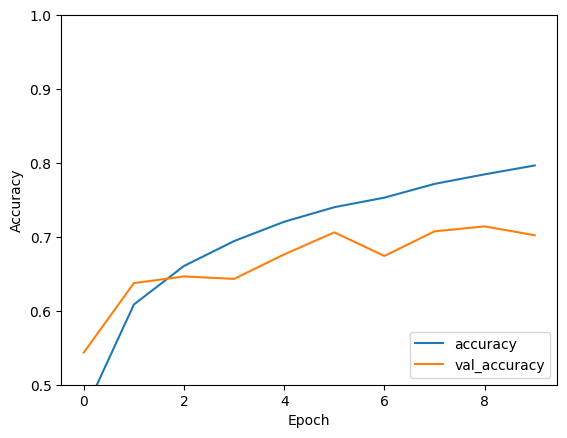

In [24]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

### 🧩 The Confusion Matrix: Where is the model making mistakes?

An overall accuracy of 70% is helpful, but we need to know exactly *where* the model is failing. A **Confusion Matrix** lays out all the predictions on a grid. 
* The **rows** represent what the image *actually* was.
* The **columns** represent what the model *guessed* it was.

By looking at this grid, we can see if the network has a hard time telling the difference between specific classes (like cats and dogs, or automobiles and trucks).

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


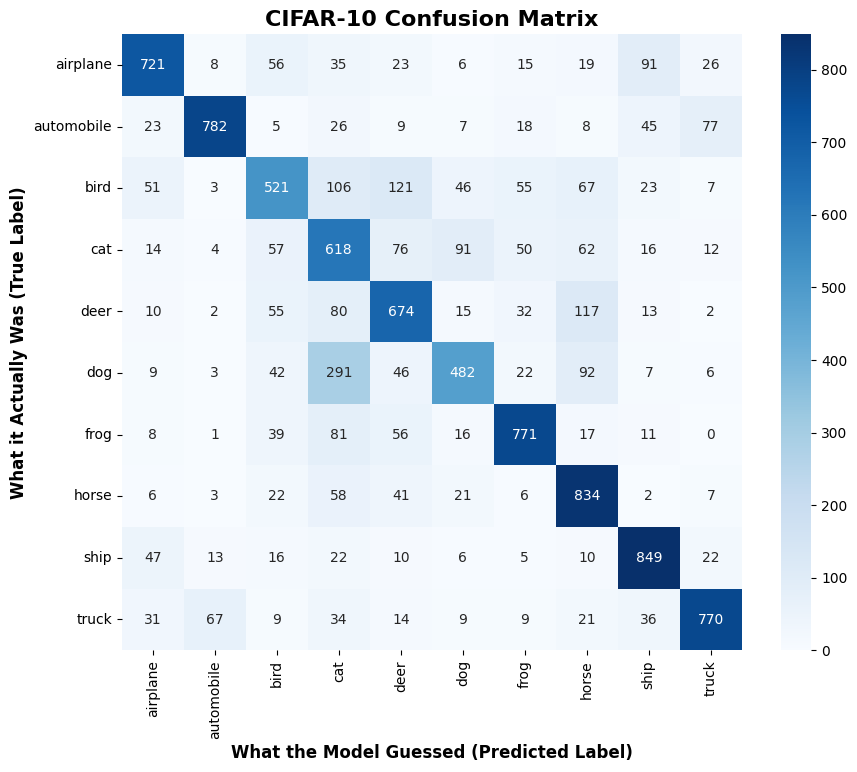

In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

 
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)
cm = confusion_matrix(test_labels, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('What the Model Guessed (Predicted Label)', fontsize=12, fontweight='bold')
plt.ylabel('What it Actually Was (True Label)', fontsize=12, fontweight='bold')
plt.title('CIFAR-10 Confusion Matrix', fontsize=16, fontweight='bold')
plt.show()

### 🛡️ Fixing Overfitting with "Dropout"

Right now, the gap between our training accuracy (~80%) and validation accuracy (~70%) tells us the model is **overfitting**. It is memorizing the specific training images rather than learning general concepts. 

To fix this, we will add a **Dropout** layer.

**How Dropout Works:**
Imagine a group project where one really smart student does 100% of the work. If that student gets sick on presentation day, the whole group fails. 

A Dropout layer acts like a strict teacher who randomly sends 50% of the students out of the room every single day of the project. To survive, *every* student is forced to learn the material, and the group becomes incredibly resilient. 

In our CNN, `Dropout(0.5)` randomly turns off 50% of the neurons during each training step. This prevents the network from relying too heavily on any single path or specific pixel, forcing it to learn robust, general patterns.

In [27]:
from tensorflow.keras import layers, models

model = models.Sequential()

# Convolutional Base 
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# The Classifier
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))

#Dropout layer
model.add(layers.Dropout(0.5))

model.add(layers.Dense(10))
model.summary()

y:\cnn-demo\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3575 - loss: 1.7299 - val_accuracy: 0.5060 - val_loss: 1.3791
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5117 - loss: 1.3686 - val_accuracy: 0.5816 - val_loss: 1.1885
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5693 - loss: 1.2165 - val_accuracy: 0.6007 - val_loss: 1.1100
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6098 - loss: 1.1177 - val_accuracy: 0.6320 - val_loss: 1.0552
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6378 - loss: 1.0441 - val_accuracy: 0.6735 - val_loss: 0.9447
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6621 - loss: 0.9763 - val_accuracy: 0.6727 - val_loss: 0.9551
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6778 - loss: 0.9316 - val_accuracy: 0.7022 - val_loss: 0.8737
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6926 - loss: 0.8863 - 

### 📉 The Impact of Dropout: Overfitting Cured

By adding the Dropout layer, we fundamentally changed how the model learns, and the graph proves it was successful. 

* 👯 **The Lines are Hugging:** In our first model, the training accuracy (blue line) shot up to nearly 80% while the validation accuracy (orange line) stalled at 70%. Now,  the two lines are very close to each other. 
* 🧠 **Generalization over Memorization:** Because we randomly forced neurons to turn off during training, the network couldn't just memorize the specific training images. It was forced to learn true, generalized patterns. 

313/313 - 0s - 1ms/step - accuracy: 0.6974 - loss: 0.8789


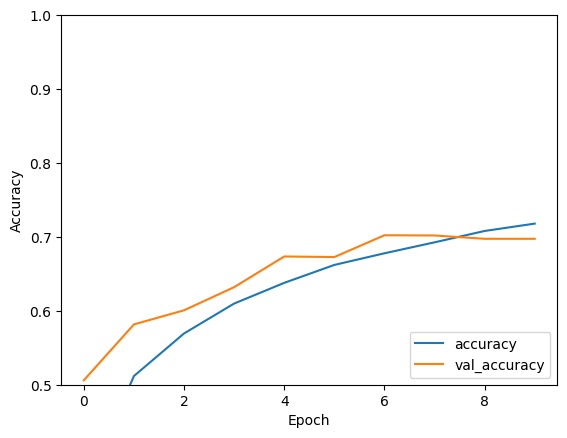

In [29]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

### 🕵️‍♂️ Analyzing the Confusion Matrix

The overall accuracy is solid, but this matrix reveals exactly what the model "sees" and where its blind spots are. 

* ✅ **The Strongest Performers:** Look at the dark blue diagonal line. The model is incredibly confident at identifying **Automobiles (856 correct)**, **Frogs (823 correct)**, and **Ships (816 correct)**. These classes likely have very distinct shapes and background colors.
* ❌ **The Animal Mix-Ups:** The model really struggles with similar animals. If you look at the `cat` row, you'll see the model incorrectly guessed it was a `dog` **183 times**. It also frequently confused birds with deer (125 times). 
* 🚗 **The Vehicle Mix-Ups:** Interestingly, while it doesn't confuse vehicles with animals, it does struggle with similar vehicles. It looked at a `truck` and incorrectly guessed `automobile` **91 times**.

**Conclusion:** The Convolutional Neural Network is doing a great job separating broad categories (animals vs. vehicles), but it needs either more data or a more complex architecture to distinguish the fine-grained details between a cat and a dog.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


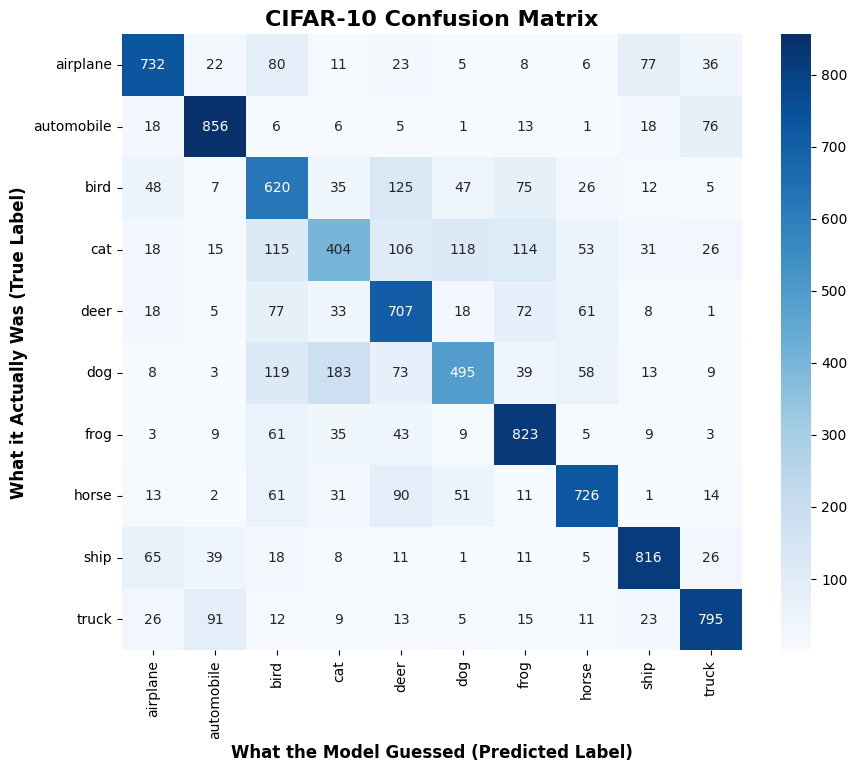

In [30]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

 
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)
cm = confusion_matrix(test_labels, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('What the Model Guessed (Predicted Label)', fontsize=12, fontweight='bold')
plt.ylabel('What it Actually Was (True Label)', fontsize=12, fontweight='bold')
plt.title('CIFAR-10 Confusion Matrix', fontsize=16, fontweight='bold')
plt.show()

### 🤌 Final Conclusion: The Power of CNNs

Traditional neural networks fail with images because they force 2D pictures into 1D lines, destroying spatial structure and requiring an impossible number of parameters. **Convolutional Neural Networks (CNNs)** solve this by looking at images exactly the way human eyes do.



**CNNs summed up:**
> *"A CNN is a specialized neural network designed for image processing. Instead of looking at every pixel at once, it uses sliding filters to scan the image for specific features, sharing parameters to save computing power. It then shrinks the data down to just the most important patterns before handing it off to a standard neural network to make a final classification."*

**The Core Pipeline:**
1. 📥 **Input:** A 3D tensor (Height, Width, RGB Colors).
2. 🕵️‍♂️ **Conv2D (The Detective):** Scans the image with small 2D filters to extract features (edges, textures, colors).
3. 🗜️ **MaxPooling2D (The Summarizer):** Shrinks the image grid, keeping only the loudest features to save memory.
4. 🥞 **Flatten (The Unroller):** Converts the final 3D block of features into a single 1D straight line.
5. ⚖️ **Dense Layers (The Judge):** Uses the unrolled evidence and outputs the final prediction.

**The Golden Rule of Training:**
A model that just memorizes the training data is useless in the real world (Overfitting). True success in machine learning isn't just about building the architecture; it's about using tools like **Dropout** to force the network to learn genuine, generalized patterns, and using **Confusion Matrices** to deeply understand its blind spots.